In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
import math
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
# Load loan-level MBS data
df = pd.read_csv('/Users/ishawadekar/Downloads/mbs/MBS_RiskManagement/regression_data.txt')
df1 = pd.DataFrame(df)
df1.head()


,Loan Sequence Number,Credit Score,Occupancy Status,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan-to-Value (LTV),Original Interest Rate,Property State,Original Loan Term,Number of Borrowers,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Remaining Months to Legal Maturity,Current Interest Rate,Current Deferred UPB,Estimated Loan-to-Value (ELTV),Default
0,NaN,629.0,P,77.0,45.0,324000.0,71.0,3.875,KY,180.0,2.0,0.00,0.0,74.0,106.0,3.875,0.0,50.0,0
1,F14Q10000001,770.0,P,89.0,30.0,65000.0,89.0,3.375,NY,180.0,2.0,0.00,0.0,40.0,140.0,3.375,0.0,999.0,0
2,F14Q10000002,674.0,P,89.0,999.0,182000.0,76.0,3.375,MI,180.0,1.0,0.00,0.0,75.0,105.0,3.375,0.0,999.0,0
3,F14Q10000003,717.0,I,77.0,41.0,107000.0,77.0,5.250,RI,360.0,2.0,84852.01,0.0,132.0,228.0,5.250,0.0,21.0,0
4,F14Q10000004,813.0,P,95.0,32.0,165000.0,95.0,4.125,IA,360.0,1.0,0.00,3.0,47.0,313.0,4.125,0.0,999.0,1


In [4]:
df1.shape

(20323122, 19)

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20323122 entries, 0 to 20323121
Data columns (total 19 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   Loan Sequence Number                    object 
 1   Credit Score                            float64
 2   Occupancy Status                        object 
 3   Original Combined Loan-to-Value (CLTV)  float64
 4   Original Debt-to-Income (DTI) Ratio     float64
 5   Original UPB                            float64
 6   Original Loan-to-Value (LTV)            float64
 7   Original Interest Rate                  float64
 8   Property State                          object 
 9   Original Loan Term                      float64
 10  Number of Borrowers                     float64
 11  Current Actual UPB                      float64
 12  Current Loan Delinquency Status         float64
 13  Loan Age                                float64
 14  Remaining Months to Legal Maturi

In [6]:
df1.describe()

,Credit Score,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan-to-Value (LTV),Original Interest Rate,Original Loan Term,Number of Borrowers,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Remaining Months to Legal Maturity,Current Interest Rate,Current Deferred UPB,Estimated Loan-to-Value (ELTV),Default
count,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.031492e+07,2.032312e+07,2.032312e+07,2.032312e+07,2.032312e+07,1.976557e+07,2.032312e+07
mean,7.524425e+02,7.307062e+01,5.500394e+01,2.696437e+05,7.270638e+01,4.004895e+00,3.248354e+02,1.483010e+00,1.398112e+05,4.227794e-02,4.249073e+01,2.830604e+02,4.002977e+00,1.457126e+02,4.316879e+02,1.035185e-02
std,1.322032e+02,1.817295e+01,1.387154e+02,1.453568e+05,1.799182e+01,1.228829e+00,6.934942e+01,5.173561e-01,1.645624e+05,7.669504e-01,2.685686e+01,7.843377e+01,1.228927e+00,2.047718e+03,4.663765e+02,1.012161e-01
min,3.000000e+02,1.000000e+00,1.000000e+00,1.000000e+03,1.000000e+00,0.000000e+00,6.000000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e+00,1.500000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,7.200000e+02,6.300000e+01,2.800000e+01,1.600000e+05,6.200000e+01,3.000000e+00,3.600000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01,2.630000e+02,3.000000e+00,0.000000e+00,4.400000e+01,0.000000e+00
50%,7.600000e+02,7.700000e+01,3.600000e+01,2.420000e+05,7.600000e+01,3.750000e+00,3.600000e+02,1.000000e+00,9.369319e+04,0.000000e+00,4.100000e+01,3.130000e+02,3.750000e+00,0.000000e+00,7.000000e+01,0.000000e+00
75%,7.880000e+02,8.500000e+01,4.300000e+01,3.520000e+05,8.500000e+01,4.500000e+00,3.600000e+02,2.000000e+00,2.374729e+05,0.000000e+00,5.400000e+01,3.340000e+02,4.500000e+00,0.000000e+00,9.990000e+02,0.000000e+00
max,9.999000e+03,9.990000e+02,9.990000e+02,2.212000e+06,9.990000e+02,9.750000e+00,5.590000e+02,9.900000e+01,2.190566e+06,1.160000e+02,1.340000e+02,5.070000e+02,9.750000e+00,3.750000e+05,9.990000e+02,1.000000e+00


In [7]:
df1.isna().sum()

Loan Sequence Number                           3
Credit Score                                   3
Occupancy Status                               3
Original Combined Loan-to-Value (CLTV)         3
Original Debt-to-Income (DTI) Ratio            3
Original UPB                                   3
Original Loan-to-Value (LTV)                   3
Original Interest Rate                         3
Property State                                 3
Original Loan Term                             3
Number of Borrowers                            3
Current Actual UPB                             3
Current Loan Delinquency Status             8200
Loan Age                                       3
Remaining Months to Legal Maturity             3
Current Interest Rate                          3
Current Deferred UPB                           3
Estimated Loan-to-Value (ELTV)            557555
Default                                        0
dtype: int64

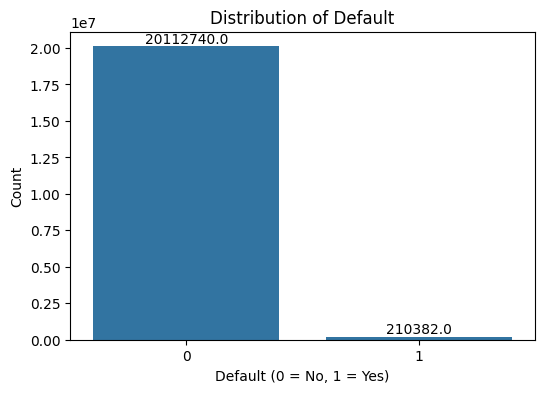

In [12]:
# Distribution of Default
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df1)
plt.title('Distribution of Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add the number of occurrences on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                       textcoords='offset points')
plt.show()

In [21]:
duration_col = 'Loan Age'
event_col = 'Default'

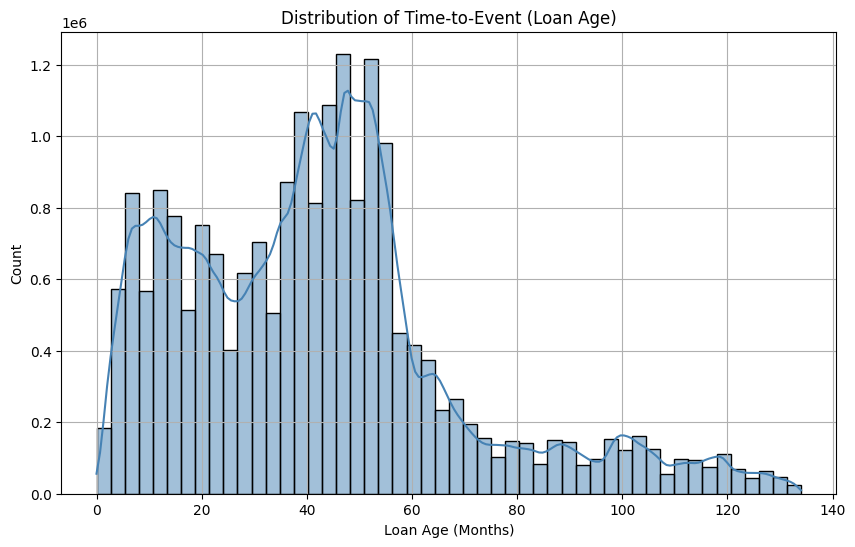

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df1[duration_col], kde=True, bins=50, color='steelblue')
plt.title('Distribution of Time-to-Event (Loan Age)')
plt.xlabel('Loan Age (Months)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [23]:
print("\nSummary Statistics for Time-to-Event (Loan Age):")
print(df1[duration_col].describe())


Summary Statistics for Time-to-Event (Loan Age):
count    2.032312e+07
mean     4.249073e+01
std      2.685686e+01
min      0.000000e+00
25%      2.200000e+01
50%      4.100000e+01
75%      5.400000e+01
max      1.340000e+02
Name: Loan Age, dtype: float64


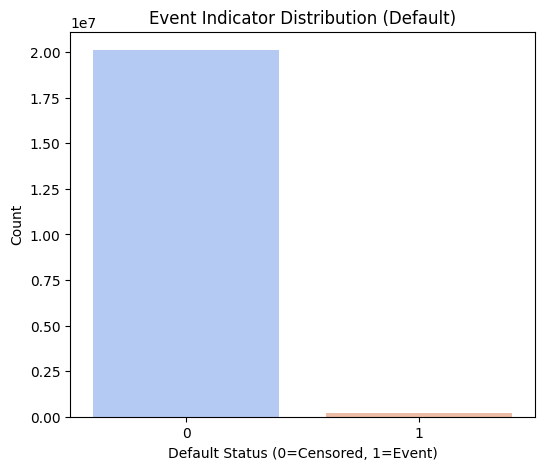


Event Distribution:
Default
0    20112740
1      210382
Name: count, dtype: int64

Event Percentage:
Default
0    98.964815
1     1.035185
Name: proportion, dtype: float64


In [24]:
event_counts = df1[event_col].value_counts(normalize=False)
event_perc = df1[event_col].value_counts(normalize=True) * 100

plt.figure(figsize=(6,5))
sns.barplot(x=event_counts.index, y=event_counts.values, palette='coolwarm')
plt.title('Event Indicator Distribution (Default)')
plt.xlabel('Default Status (0=Censored, 1=Event)')
plt.ylabel('Count')
plt.show()

print("\nEvent Distribution:")
print(event_counts)
print("\nEvent Percentage:")
print(event_perc)

In [38]:
df1 = df1[(df1['Credit Score'] >= 300) & (df1['Credit Score'] <= 850)] 
df1.shape

(20319455, 19)

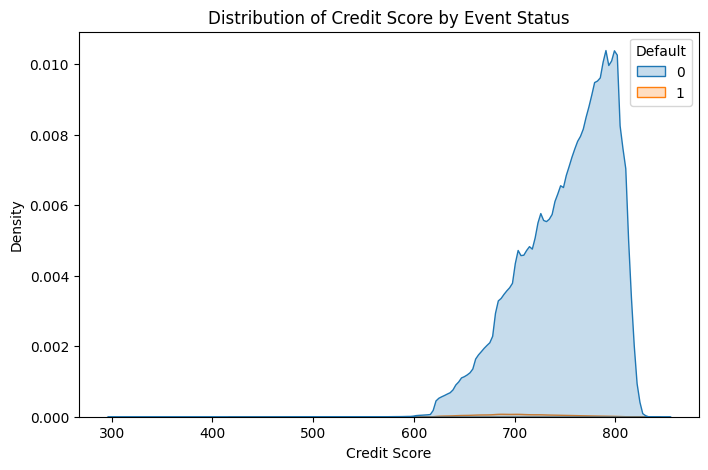

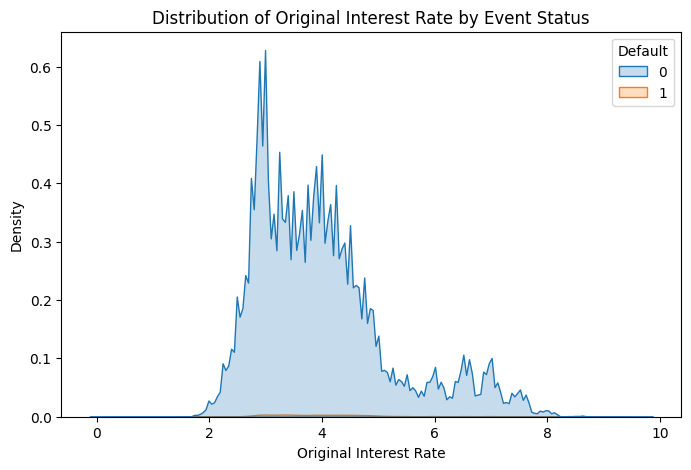

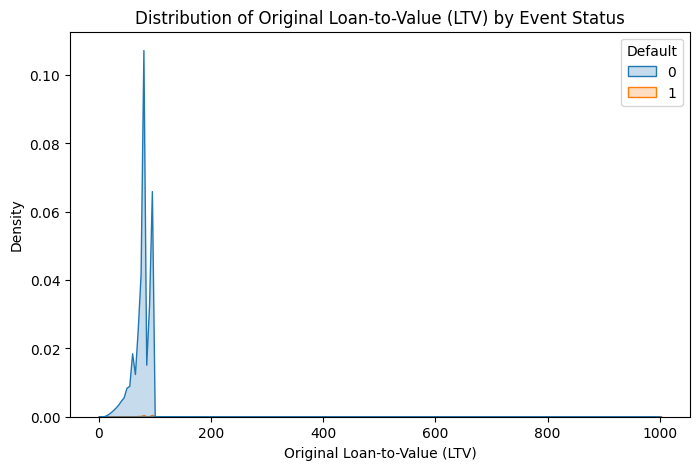

In [39]:
# --- 5. Censoring Mechanism Check ---
# Compare covariates (like Credit Score, Interest Rate, LTV) across censored vs uncensored
covariates = ['Credit Score', 'Original Interest Rate', 'Original Loan-to-Value (LTV)']

for cov in covariates:
    plt.figure(figsize=(8,5))
    sns.kdeplot(data=df1, x=cov, hue=event_col, fill=True)
    plt.title(f'Distribution of {cov} by Event Status')
    plt.xlabel(cov)
    plt.ylabel('Density')
    plt.show()

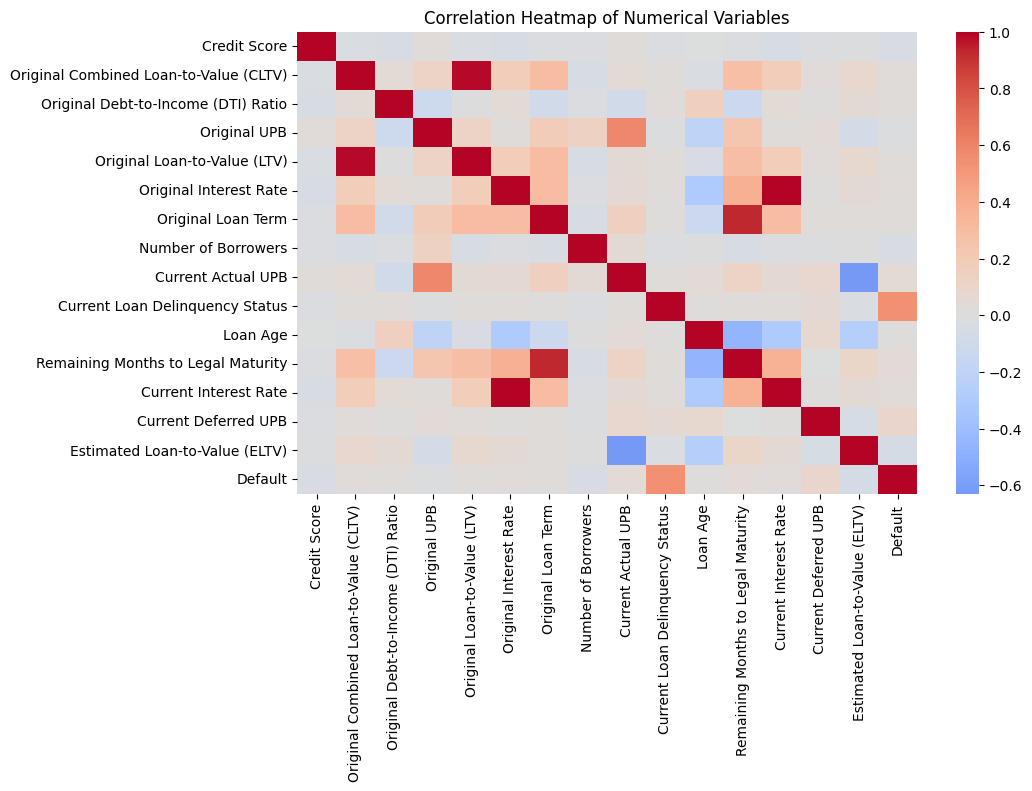

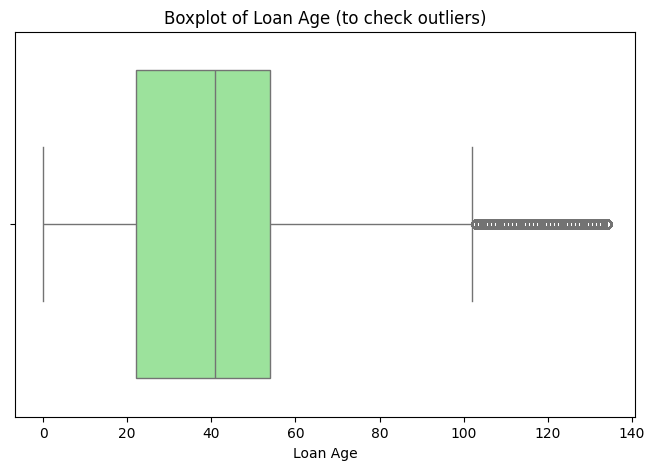


Skewness of Loan Age: 0.92


In [28]:
# --- 6. Optional: Correlation Between Key Covariates ---
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

# --- 7. Check for Skewness & Outliers in Time Variable ---
plt.figure(figsize=(8,5))
sns.boxplot(x=df1[duration_col], color='lightgreen')
plt.title('Boxplot of Loan Age (to check outliers)')
plt.show()

skewness = stats.skew(df1[duration_col].dropna())
print(f"\nSkewness of Loan Age: {skewness:.2f}")

ASSUMPTION TESTING

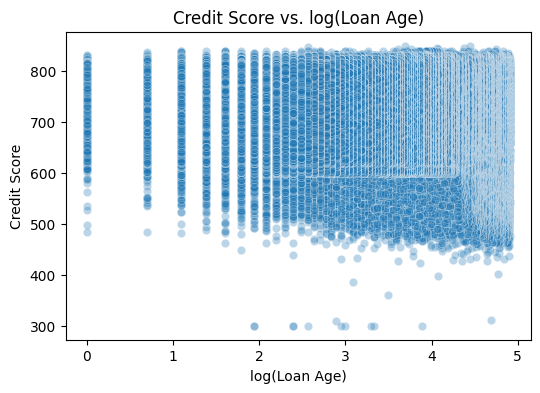

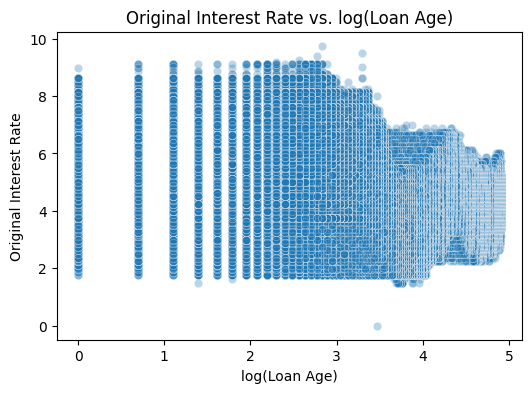

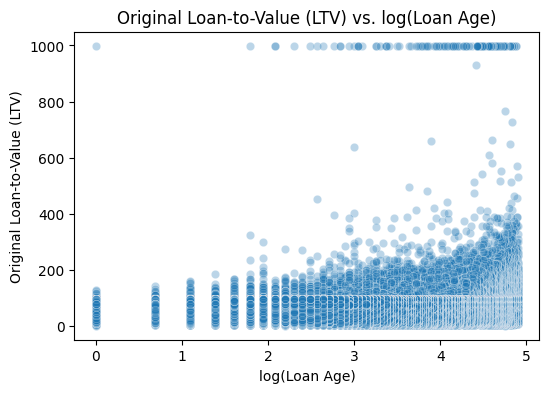

In [50]:
time_col = 'Loan Age'
covariates = ['Credit Score', 'Original Interest Rate', 'Original Loan-to-Value (LTV)']

for cov in covariates:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=np.log(df1[time_col]+1), y=df1[cov], alpha=0.3)
    plt.title(f'{cov} vs. log(Loan Age)')
    plt.xlabel('log(Loan Age)')
    plt.ylabel(cov)
    plt.show()

In [ ]:
# Categorical variables = ['Occupancy Status', 'Property State']

In [ ]:
print(df['Occupancy Status'].value_counts()) # do Ordinal Encoding - logic: endowment effect
print(df['Property State'].value_counts()) # do One Hot Encoding - logic: cardinal variables

Occupancy Status
P    18272505
I     1356072
S      694542
Name: count, dtype: int64
Property State
CA    2626139
TX    1514100
FL    1354022
IL     897933
OH     744338
MI     720255
AZ     675962
GA     635421
NC     631904
CO     622879
WA     622655
NY     617990
PA     615233
VA     571828
NJ     547509
IN     475455
MA     469279
MN     460299
MD     415998
MO     413937
TN     405866
OR     365133
WI     363317
UT     355762
SC     318859
KY     249526
NV     240372
AL     219019
CT     201907
LA     183917
IA     168287
KS     163632
OK     160294
ID     148784
AR     131308
NH     109503
NE     100034
NM      87883
ME      79769
DE      74789
MT      71347
MS      70767
RI      63936
HI      56134
WV      53320
DC      45707
VT      42481
ND      42125
SD      40764
AK      35943
WY      31911
PR       3716
GU       2546
VI       1325
Name: count, dtype: int64


In [ ]:
# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[['P', 'S', 'I']]), ['Occupancy Status']),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), ['Property State'])
    ],
    remainder='passthrough' # Keep all other columns as is
)

# Apply the transformations
# Note: This returns a NumPy array, so you'd typically integrate this into a model pipeline.
# For quick EDA, let's just transform:
transformed_data = preprocessor.fit_transform(df1)

print("\n--- Unified ColumnTransformer Output Shape (NumPy Array) ---")
print(transformed_data.shape)


--- Unified ColumnTransformer Output Shape (NumPy Array) ---
(20319455, 71)


In [49]:
td = pd.DataFrame(transformed_data)
df2 = td.drop(columns=['Loan Sequence Number'])
df2.columns

KeyError: "['Loan Sequence Number'] not found in axis"

In [ ]:
# --- 1. Fit the Cox Proportional Hazards Model ---
cph = CoxPHFitter()

# Ensure your duration and event columns match your data
# Duration column: 'week' (time-to-event)
# Event column: 'arrest' (1=event, 0=censored)
cph.fit(df2, duration_col='Loan Age', event_col='Default')

# --- 2. Plot the Schoenfeld Residuals (The Easiest Way) ---

# The .check_assumptions() method automatically plots the scaled Schoenfeld residuals
# for all covariates against time, complete with confidence intervals and a smoothed line.

cph.check_assumptions(df2, p_value_threshold=0.05, show_plots=True)

# Interpretation:
# For the Proportional Hazards assumption to hold, the smoothed line (typically a red or blue line) 
# for each covariate should be statistically flat (horizontal) and close to zero. 
# A trend or curve indicates a violation of the assumption for that covariate.

plt.show()

ValueError: could not convert string to float: 'P'